In [1]:
%pip uninstall latentmi -y
%pip install git+https://github.com/0kutsu/latentmi

Found existing installation: latentmi 0.1.3
Uninstalling latentmi-0.1.3:
  Successfully uninstalled latentmi-0.1.3
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/0kutsu/latentmi to /tmp/pip-req-build-8e99xosv
  Running command git clone --filter=blob:none --quiet https://github.com/0kutsu/latentmi /tmp/pip-req-build-8e99xosv
  Resolved https://github.com/0kutsu/latentmi to commit a95ec552314fdc4d786a2323f69284fb4425e006
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for latentmi: filename=latentmi-0.1.3-py3-none-any.whl size=9991 sha256=fbb52d6ccd4cfb6dde85cceb910a876b2d719f8ff088f2afbe04c022f41b3890
  Stored in directory: /tmp/pip-ephem-wheel-cache-m405aw6q/wheels/c1/bd/07/953b6a903fd435834eb94f09dad6fed0cee2fcb3cb879a26d6
Successfully built latentmi
Note: you may need to restart the kernel to use updated packages.


In [2]:
from zoneinfo import ZoneInfo
from datetime import datetime

# CURRENT TIME METHOD
def current_time():
    # Gets the current local date and time
    now = datetime.now(ZoneInfo("America/New_York"))
    
    # Formats and prints just the time (Hour:Minute:Second)
    current_time = now.strftime("%H:%M:%S")
    return current_time

In [6]:
# Z SCORE
from latentmi import lmi
import torch
import numpy as np
import gc

torch.manual_seed(1)
np.random.seed(1)

truth_mi = -0.5*np.log2((1-(4/(np.sqrt(6*3.5)))**2)) # 1.035 bits
trials = 100
k = 20
n_dims = 8

print("Time,Trial,LMI Estimate,Variance Estimate,Variance Error")

lmi_estimates = np.empty(trials)
stdvar_estimates = np.empty(trials)
for i in range(trials):
    print(f"{current_time()},{i + 1},", end = "")

    intrinsic = np.random.multivariate_normal(mean=[0, 0], cov=[[6, 4], [4, 3.5]], size=2000)

    # reparameterizing 
    X_intrinsic = intrinsic[:, [0]]
    Y_intrinsic = intrinsic[:, [1]]
                                            
    X_proj = np.random.normal(size=(1, 100))
    Y_proj = np.random.normal(size=(1, 100))

    Xs = X_intrinsic @ X_proj
    Ys = Y_intrinsic @ Y_proj
    
    # LMI estimation
    pmis, _, _ = lmi.estimate(Xs, Ys, regularizer='models.AECross', alpha=1, lam=1, N_dims=n_dims, k=k, 
                              validation_split=0.5, estimate_on_val=True, batch_size=512, lr=0.0001, 
                              epochs=300, patience=30, quiet=True, device=None)
    lmi_estimates[i] = np.nanmean(pmis)

    # variance estimation
    var_estimate, var_error = lmi.estimate_variance(Xs, Ys, n_partitions=9, regularizer='models.AECross', 
                                                    alpha=1, lam=1, N_dims=n_dims, k=k, validation_split=0.5, 
                                                    estimate_on_val=True, batch_size=512, lr=0.0001, epochs=300, 
                                                    patience=30, quiet=True, device=None)
    stdvar_estimates[i] = np.sqrt(var_estimate)

    print(f"%.6f,%.6f,%.6f" % (lmi_estimates[i], var_estimate, var_error))

    torch.cuda.empty_cache()
    gc.collect()

z_scores = (lmi_estimates - truth_mi) / stdvar_estimates

print("\nMean of z-scores: %.6f" % np.mean(z_scores))
print("Standard deviation of z-scores: %.6f" % np.std(z_scores))

Time,Trial,LMI Estimate,Variance Estimate,Variance Error
12:59:56,1,1.034872,0.001327,0.000280
13:00:49,2,1.042236,0.000800,0.000169
13:01:41,3,1.053226,0.001455,0.000307
13:02:34,4,1.035487,0.001029,0.000217
13:03:26,5,1.043622,0.001440,0.000304
13:04:16,6,1.059638,0.001759,0.000371
13:05:07,7,1.051888,0.001051,0.000221
13:06:00,8,1.061823,0.001553,0.000327
13:06:51,9,0.979050,0.001786,0.000377
13:07:44,10,1.100375,0.001401,0.000295
13:08:34,11,1.096434,0.001385,0.000292
13:09:28,12,1.050761,0.001367,0.000288
13:10:20,13,1.076223,0.001710,0.000361
13:11:10,14,0.955338,0.001219,0.000257
13:12:02,15,1.037582,0.000686,0.000145
13:12:51,16,1.073872,0.001119,0.000236
13:13:41,17,0.965169,0.001271,0.000268
13:14:32,18,1.049103,0.001359,0.000286
13:15:26,19,1.069421,0.001296,0.000273
13:16:17,20,1.075888,0.001461,0.000308
13:17:09,21,0.953084,0.001582,0.000334
13:17:59,22,1.070533,0.000949,0.000200
13:18:52,23,1.020274,0.001101,0.000232
13:19:46,24,0.946635,0.000986,0.000208
13:20:36,25,1.06

Timestamp,Sample Size,Variance Estimate,Standard Error,LMI Estimate
12:52:46,600,0.001040,0.000219,1.022061
12:53:21,700,0.001651,0.000348,1.100402
12:53:53,800,0.001374,0.000290,0.985097
12:54:27,900,0.001399,0.000295,1.121426
12:55:00,1000,0.001223,0.000258,1.006536
12:55:35,2000,0.001158,0.000244,1.038065
12:56:14,3000,0.001181,0.000249,1.095370
12:56:55,4000,0.000929,0.000196,1.030437
12:57:42,5000,0.000679,0.000143,1.113130
12:58:28,6000,0.000555,0.000117,1.066823
12:59:20,7000,0.000390,0.000082,1.071862
13:00:22,8000,0.000535,0.000113,1.093959
13:01:29,9000,0.000372,0.000078,1.078006
13:02:39,10000,0.000432,0.000091,1.036651


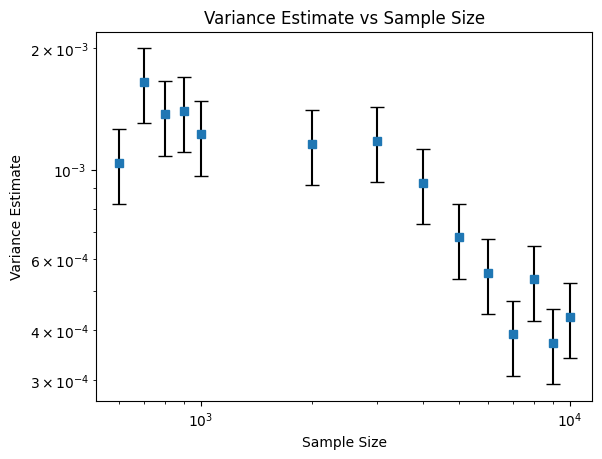

In [9]:
# SANITY CHECKING VARIANCE ESTIMATES
from latentmi import lmi
import torch 
import numpy as np
import gc
import matplotlib.pyplot as plt

torch.manual_seed(1)
np.random.seed(1)
k = 20
n_dims = 2

sample_sizes = [600, 700, 800, 900,
                1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000,
                10000]

print("Timestamp,Sample Size,Variance Estimate,Standard Error,LMI Estimate")

variance_estimates = np.empty((len(sample_sizes), 3)) # cols: sample size, variance estimate, variance error
for i in range(len(sample_sizes)):
    sample_size = sample_sizes[i]
    print(f"{current_time()},{sample_size},", end = "")

    intrinsic = np.random.multivariate_normal(mean=[0, 0], cov=[[6, 4], [4, 3.5]], size=sample_size)

    # reparameterizing 
    X_intrinsic = intrinsic[:, [0]]
    Y_intrinsic = intrinsic[:, [1]]
                                            
    X_proj = np.random.normal(size=(1, 100))
    Y_proj = np.random.normal(size=(1, 100))

    Xs = X_intrinsic @ X_proj
    Ys = Y_intrinsic @ Y_proj
    
    # lmi estimation
    pmis, _, _ = lmi.estimate(Xs, Ys, regularizer='models.AECross', alpha=1, lam=1, N_dims=n_dims, k=k, 
                              validation_split=0.5, estimate_on_val=True, batch_size=512, lr=0.0001, 
                              epochs=300, patience=30, quiet=True, device=None)
    lmi_estimate = np.nanmean(pmis)
    # variance estimation
    var_estimate, var_error = lmi.estimate_variance(Xs, Ys, n_partitions=9, regularizer='models.AECross', 
                                                    alpha=1, lam=1, N_dims=n_dims, k=k, validation_split=0.5, 
                                                    estimate_on_val=True, batch_size=512, lr=0.0001, epochs=300, 
                                                    patience=30, quiet=True, device=None)
    variance_estimates[i] = [sample_size, var_estimate, var_error]

    print("%.6f,%.6f,%.6f" % (var_estimate, var_error, lmi_estimate))

    torch.cuda.empty_cache()
    gc.collect()

# creating a scatter plot
plt.errorbar(variance_estimates[:, 0],  variance_estimates[:, 1], yerr=variance_estimates[:, 2], fmt='s', ecolor='black', capsize=5)
plt.xlabel('Sample Size')
plt.ylabel('Variance Estimate')
plt.title('Variance Estimate vs Sample Size')

plt.xscale('log')
plt.yscale('log')

plt.show()

In [ ]:
# TESTING KSG

from latentmi import ksg
import torch
import numpy as np
import gc

torch.manual_seed(1)
np.random.seed(1)

truth_mi = -0.5*np.log2((1-(4/(np.sqrt(6*3.5)))**2)) # 1.035 bits
trials = 100

k = 20

print("Time,Trial,LMI Estimate,Variance Estimate,Variance Error")

ksg_estimates = np.empty(trials)
stdvar_estimates = np.empty(trials)
for i in range(trials):
    print(f"{current_time()},{i + 1},", end = "")

    intrinsic = np.random.multivariate_normal(mean=[0, 0], cov=[[6, 4], [4, 3.5]], size=2000)

    # reparameterizing 
    X_intrinsic = intrinsic[:, [0]]
    Y_intrinsic = intrinsic[:, [1]]
                                            
    X_proj = np.random.normal(size=(1, 100))
    Y_proj = np.random.normal(size=(1, 100))

    Xs = X_intrinsic @ X_proj
    Ys = Y_intrinsic @ Y_proj
    
    # KSG estimation
    ksgs = ksg.mi(Xs, Ys, k=k, z=None, base=2, alpha=0)

    # variance estimation
    var_estimate, var_error = ksg.estimate_variance(Xs, Ys, k=k, z=None, base=2, alpha=0)
    stdvar_estimates[i] = np.sqrt(var_estimate)

    print(f"%.6f,%.6f,%.6f" % (lmi_estimates[i], var_estimate, var_error))

    torch.cuda.empty_cache()
    gc.collect()

z_scores = (lmi_estimates - truth_mi) / stdvar_estimates

print("\nMean of z-scores: %.6f" % np.mean(z_scores))
print("Standard deviation of z-scores: %.6f" % np.std(z_scores))